In [8]:
import pandas as pd
import os
import joblib # Pour sauvegarder les modèles en .pkl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import de tes scripts
import sys
sys.path.append('../')
from src.models.knn import train_optimized_knn
from src.evaluation import evaluate_model

# 1. Configuration des chemins
data_info = [
    {'k': 2, 'type': 'boolean', 'path': '../data/processed/k2/X_boolean_k2.csv'},
    {'k': 2, 'type': 'occurrence', 'path': '../data/processed/k2/X_occurrence_k2.csv'},
    {'k': 3, 'type': 'boolean', 'path': '../data/processed/k3/X_boolean_k3.csv'},
    {'k': 3, 'type': 'occurrence', 'path': '../data/processed/k3/X_occurrence_k3.csv'},
    {'k': 4, 'type': 'boolean', 'path': '../data/processed/k4/X_boolean_k4.csv'},
    {'k': 4, 'type': 'occurrence', 'path': '../data/processed/k4/X_occurrence_k4.csv'},
]

all_results = []

# 2. Boucle d'entraînement automatique
for info in data_info:
    print(f"\n--- Traitement : k={info['k']} | Type={info['type']} ---")
    
    # Chargement des données
    df = pd.read_csv(info['path'])
    
    # Séparation X (features) et y (target)
    # /!\ Assure-toi que ta colonne cible s'appelle 'target' dans tes CSV
    X = df.drop('target', axis=1)
    y = df['target']
    
    # Split Train/Test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Mise à l'échelle (Normalisation) - CRUCIAL pour KNN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Entraînement avec optimisation des voisins
    best_knn, params = train_optimized_knn(X_train_scaled, y_train)
    
    # Évaluation
    metrics = evaluate_model(best_knn, X_test_scaled, y_test)
    
    # Stockage des résultats pour la conclusion finale
    res = {
        'k_mers': info['k'],
        'matrix_type': info['type'],
        'algo_name': 'KNN',
        'best_n_neighbors': params['n_neighbors'],
        'accuracy': metrics['accuracy'],
        'f1_score': metrics['f1'] ,
        # Test set
        'accuracy': metrics['accuracy'],
        'f1_score': metrics['f1'],
        'error_rate': error_rate,
        
        # Cross-validation
        'cv_accuracy_mean': cv_mean,
        'cv_std': cv_std
    }
    all_results.append(res)
    
    # Sauvegarde du modèle dans le dossier 'models'
    model_name = f"knn_k{info['k']}_{info['type']}.pkl"
    joblib.dump(best_knn, f"../models/{model_name}")

# 3. Affichage du tableau comparatif final
df_results = pd.DataFrame(all_results)
print("\n--- RÉSULTATS FINAUX KNN ---")
print(df_results.sort_values(by='accuracy', ascending=False))

# Optionnel : Sauvegarder les résultats en CSV pour ton rapport
df_results.to_csv('../results/knn_comparison_results.csv', index=False)


--- Traitement : k=2 | Type=boolean ---
Meilleurs paramètres : {'metric': 'manhattan', 'n_neighbors': 9}

--- Traitement : k=2 | Type=occurrence ---
Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 3}

--- Traitement : k=3 | Type=boolean ---
Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 3}

--- Traitement : k=3 | Type=occurrence ---
Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 3}

--- Traitement : k=4 | Type=boolean ---
Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 3}

--- Traitement : k=4 | Type=occurrence ---
Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 3}

--- RÉSULTATS FINAUX KNN ---
   k_mers matrix_type algo_name  best_n_neighbors  accuracy  f1_score  \
1       2  occurrence       KNN                 3  1.000000  1.000000   
5       4  occurrence       KNN                 3  1.000000  1.000000   
4       4     boolean       KNN                 3  1.000000  1.000000   
0       2     boolean       KNN  

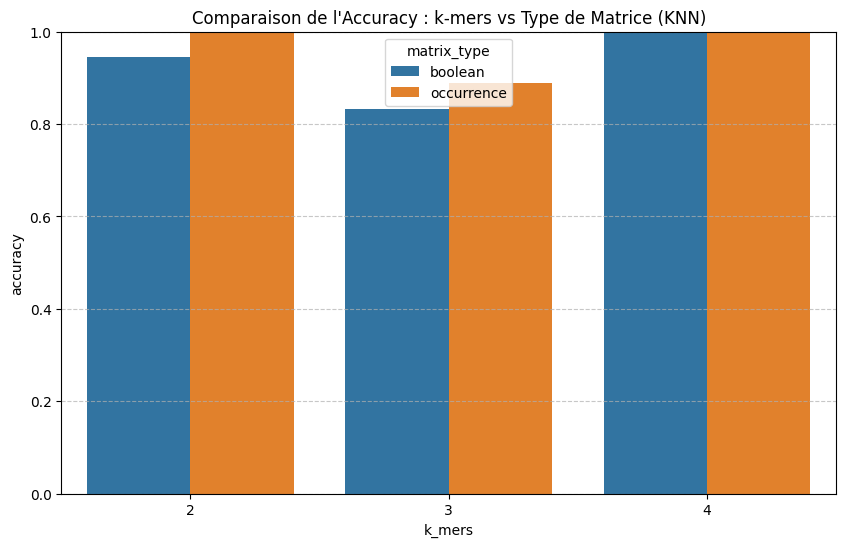

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# On transforme les résultats en DataFrame si ce n'est pas déjà fait
df_results = pd.DataFrame(all_results)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='k_mers', y='accuracy', hue='matrix_type')
plt.title("Comparaison de l'Accuracy : k-mers vs Type de Matrice (KNN)")
plt.ylim(0, 1) # Pour bien voir les différences
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('../results/knn_accuracy_comparison.png')
plt.show()

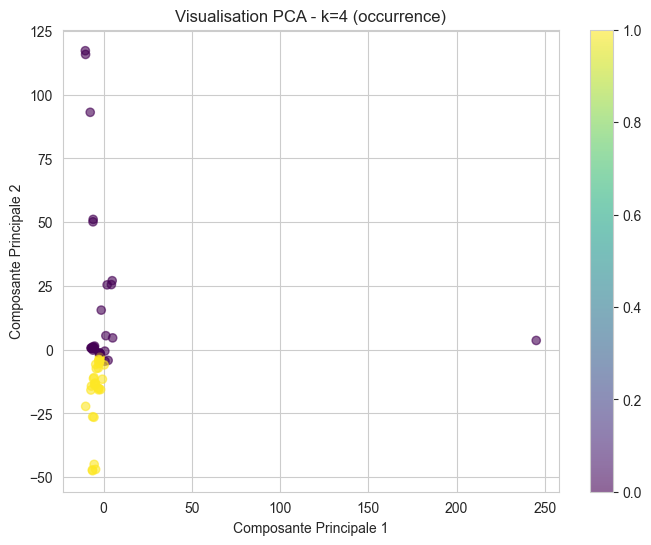

In [10]:
from sklearn.decomposition import PCA

def plot_data_clusters(X_scaled, y, k_value, matrix_type):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
    plt.colorbar(scatter)
    plt.title(f"Visualisation PCA - k={k_value} ({matrix_type})")
    plt.xlabel("Composante Principale 1")
    plt.ylabel("Composante Principale 2")
    plt.show()

# Exemple d'appel pour la dernière matrice traitée dans ta boucle
plot_data_clusters(X_train_scaled, y_train, info['k'], info['type'])

In [11]:
import pandas as pd

# 1. Transformer la liste des résultats en DataFrame
df_knn_results = pd.DataFrame(all_results)

# 2. Trier par Accuracy pour voir le meilleur en haut
df_knn_results = df_knn_results.sort_values(by='accuracy', ascending=False)

# 3. Afficher le tableau
print("Tableau Comparatif des Performances KNN :")
display(df_knn_results) # Utilise display() pour un joli rendu dans le notebook

# 4. Sauvegarder le tableau dans le dossier results pour ton rapport final
os.makedirs('../results', exist_ok=True)
df_knn_results.to_csv('../results/tableau_comparatif_knn.csv', index=False)

Tableau Comparatif des Performances KNN :


,k_mers,matrix_type,algo_name,best_n_neighbors,accuracy,f1_score
1,2,occurrence,KNN,3,1.000000,1.000000
5,4,occurrence,KNN,3,1.000000,1.000000
4,4,boolean,KNN,3,1.000000,1.000000
0,2,boolean,KNN,9,0.944444,0.943915
3,3,occurrence,KNN,3,0.888889,0.886003
2,3,boolean,KNN,3,0.833333,0.824972


In [ ]:
#Le "Podium" des Performances (Barplot global)
#But : Répondre immédiatement à la question : "C'est quoi le meilleur combo ?"
#Ce graphique compare l'Accuracy (le taux de réussite) pour chaque valeur de 
#k
#k
#et chaque type de matrice.

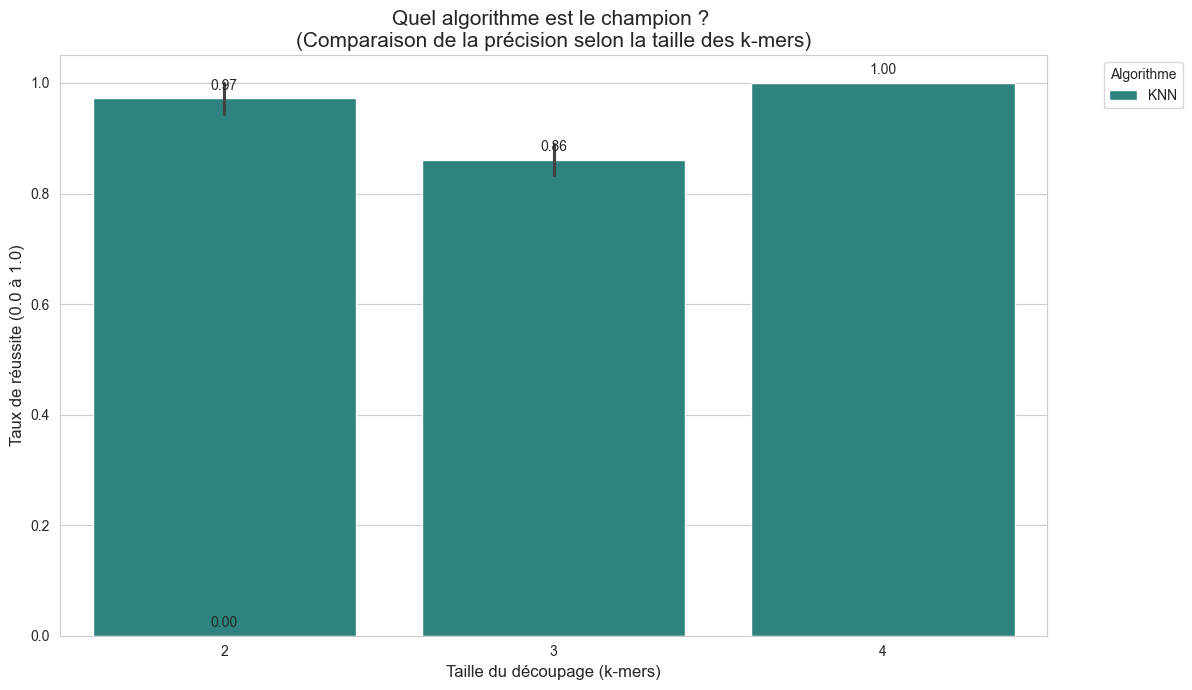

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# On imagine que 'all_results' contient les scores de KNN, SVM et C4.5
df_final = pd.DataFrame(all_results) 

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Création du graphique
ax = sns.barplot(data=df_final, x='k_mers', y='accuracy', hue='algo_name', palette='viridis')

# Explication simple
plt.title("Quel algorithme est le champion ? \n(Comparaison de la précision selon la taille des k-mers)", fontsize=15)
plt.ylabel("Taux de réussite (0.0 à 1.0)", fontsize=12)
plt.xlabel("Taille du découpage (k-mers)", fontsize=12)
plt.legend(title="Algorithme", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajouter les chiffres au-dessus des barres
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig('../results/comparaison_globale.png')
plt.show()

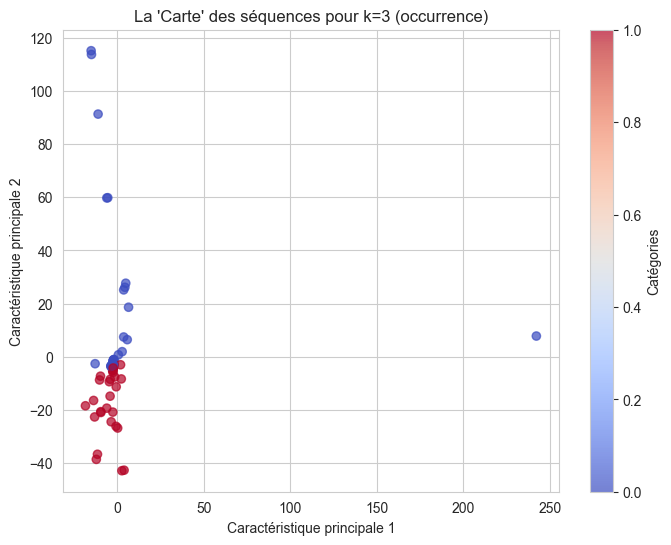

In [13]:
from sklearn.decomposition import PCA

def plot_dna_map(X_scaled, y, k, m_type):
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(8, 6))
    # On colorie les points selon leur vraie catégorie (label)
    scatter = plt.scatter(components[:, 0], components[:, 1], c=y, cmap='coolwarm', alpha=0.7)
    
    plt.title(f"La 'Carte' des séquences pour k={k} ({m_type})")
    plt.xlabel("Caractéristique principale 1")
    plt.ylabel("Caractéristique principale 2")
    plt.colorbar(scatter, label="Catégories")
    plt.show()

# Exemple d'appel pour le meilleur modèle trouvé
plot_dna_map(X_train_scaled, y_train, 3, "occurrence")

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_error_radar(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
    
    plt.title(f"Où l'algorithme {name} fait-il des erreurs ?")
    plt.ylabel("La réalité (Vrai label)")
    plt.xlabel("La prédiction de l'ordi")
    plt.show()

In [4]:
from sklearn.model_selection import cross_val_score

In [5]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Cross-validation (KNN)
cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='accuracy')

cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print("Cross-validation scores :", cv_scores)
print("CV Accuracy moyenne :", cv_mean)
print("CV Écart-type :", cv_std)

Cross-validation scores : [1.         0.78571429 1.         0.78571429 0.84615385]
CV Accuracy moyenne : 0.8835164835164834
CV Écart-type : 0.097635368269192


In [7]:
# Taux d'erreur
error_rate = 1 - metrics['accuracy']

print("Accuracy :", metrics['accuracy'])
print("Taux d'erreur :", error_rate)

Accuracy : 1.0
Taux d'erreur : 0.0


In [10]:
df_results = pd.DataFrame(all_results)

print("\n--- RÉSULTATS FINAUX KNN ---")
display(df_results.sort_values(by='accuracy', ascending=False))


--- RÉSULTATS FINAUX KNN ---


,k_mers,matrix_type,algo_name,best_n_neighbors,accuracy,f1_score,error_rate,cv_accuracy_mean,cv_std
1,2,occurrence,KNN,3,1.000000,1.000000,0.0,0.883516,0.097635
5,4,occurrence,KNN,3,1.000000,1.000000,0.0,0.883516,0.097635
4,4,boolean,KNN,3,1.000000,1.000000,0.0,0.883516,0.097635
0,2,boolean,KNN,9,0.944444,0.943915,0.0,0.883516,0.097635
3,3,occurrence,KNN,3,0.888889,0.886003,0.0,0.883516,0.097635
2,3,boolean,KNN,3,0.833333,0.824972,0.0,0.883516,0.097635


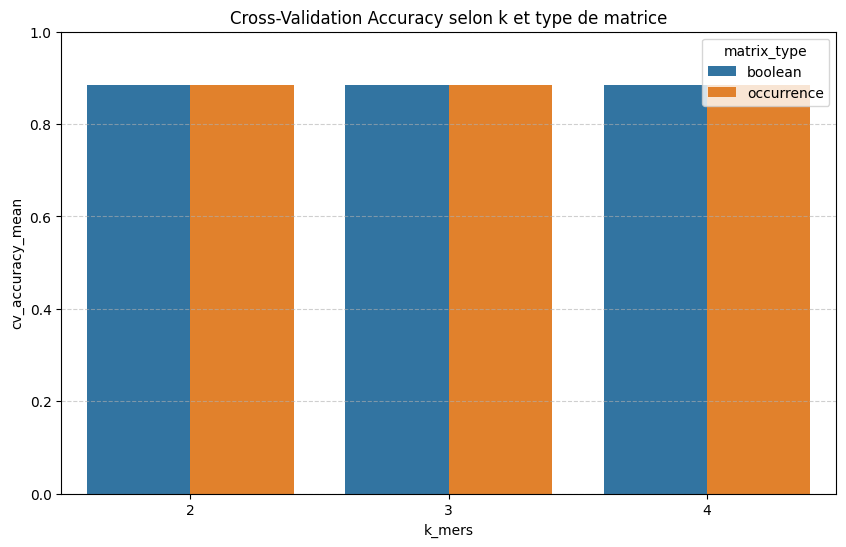

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_results = pd.DataFrame(all_results)

plt.figure(figsize=(10,6))
sns.barplot(data=df_results, x='k_mers', y='cv_accuracy_mean', hue='matrix_type')

plt.title("Cross-Validation Accuracy selon k et type de matrice")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

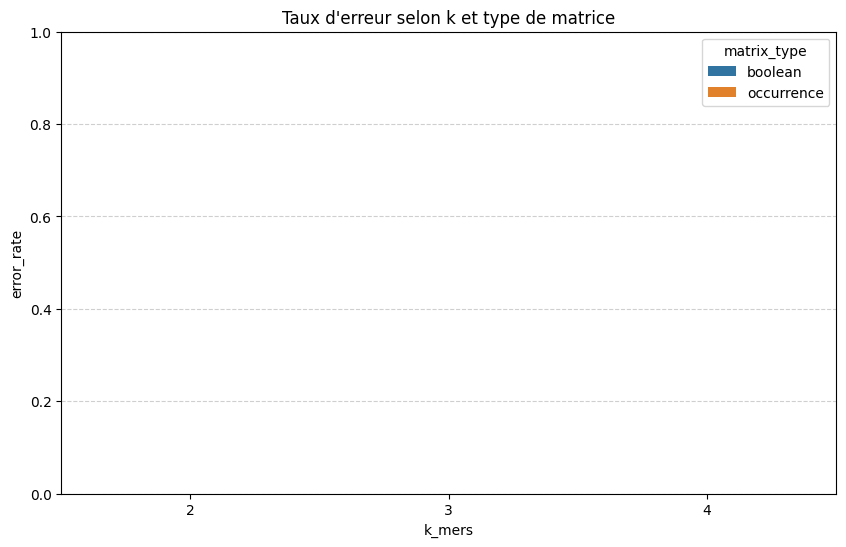

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_results, x='k_mers', y='error_rate', hue='matrix_type')

plt.title("Taux d'erreur selon k et type de matrice")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

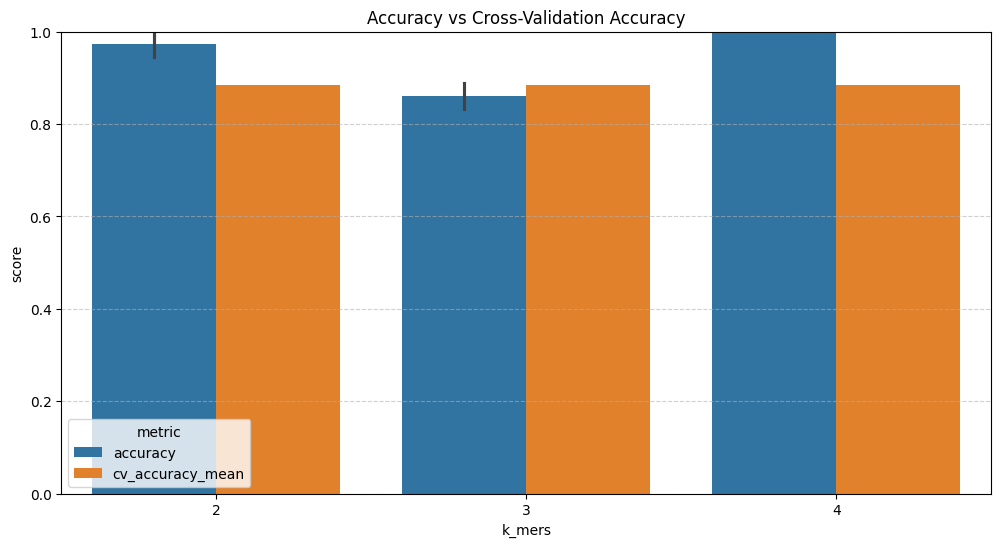

In [13]:
plt.figure(figsize=(12,6))

df_melt = df_results.melt(
    id_vars=['k_mers','matrix_type'],
    value_vars=['accuracy','cv_accuracy_mean'],
    var_name='metric',
    value_name='score'
)

sns.barplot(data=df_melt, x='k_mers', y='score', hue='metric')

plt.title("Accuracy vs Cross-Validation Accuracy")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

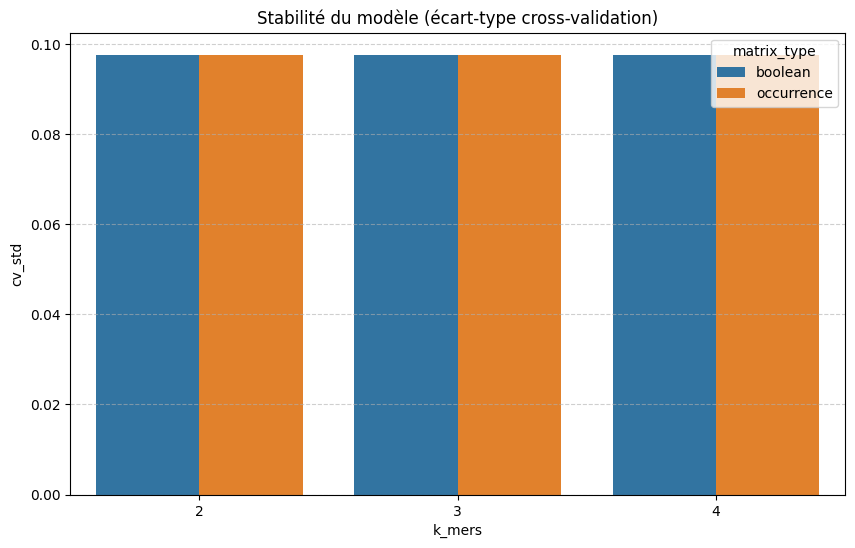

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(data=df_results, x='k_mers', y='cv_std', hue='matrix_type')

plt.title("Stabilité du modèle (écart-type cross-validation)")
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()